# Feature Engineering

This notebook separates the engineered-feature workflow into clear cells so every derived variable has a visible rationale and an auditable implementation.


## Notebook Setup

The next cells import the feature-engineering libraries, configure the plotting style, and load the processed splits used to build engineered variables.


In [1]:
# Import warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

# Import core data manipulation and viz libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


<details>
<summary><b>Explanation</b></summary>
<br>
Loads foundational Python data manipulation and graphing toolkits. Suppressing warnings guarantees our terminal output remains focused strictly on data behavior without deprecation noise.
</details>

In [2]:
# Import statistical and machine learning tools from SciPy and Scikit-Learn
from scipy import stats
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance


<details>
<summary><b>Explanation</b></summary>
<br>
Pulls in scientific testing tools (`scipy.stats`) and Scikit-Learn utilities for transformations (PCA) and evaluation metrics.
</details>

In [3]:
# Update matplotlib globals for a cohesive dark-themed aesthetic
plt.rcParams.update({
    'figure.dpi': 140,
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'axes.grid': True,
    'grid.alpha': 0.6,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

# Define custom color palettes for consistency across plots
PALETTE = {
    'primary': '#58a6ff',
    'secondary': '#bc8cff',
    'accent': '#ff7b72',
    'success': '#3fb950',
    'warning': '#d29922',
    'gradient': ['#58a6ff', '#bc8cff', '#ff7b72', '#3fb950', '#d29922', '#f778ba'],
    'sequential': sns.color_palette('mako', 10),
    'diverging': sns.color_palette('coolwarm', 10),
}

# Set globally reproducible random seed
SEED = 42
np.random.seed(SEED)
print('Environment ready for notebook execution.')


Environment ready for notebook execution.


<details>
<summary><b>Explanation</b></summary>
<br>
Standardizes the UI look-and-feel of our graphs to a sleek, dark Github-style palette, ensuring all outputs are visually contiguous when embedded into reports.
</details>

### Code Block Explanation
This cell loads the processed splits used as the base tables for the engineered features.


In [4]:
# ── Load pre-processed train / val / test splits ────────────────
PROC = '../data/processed/'

train = pd.read_csv(PROC + 'train.csv')
val   = pd.read_csv(PROC + 'val.csv')
test  = pd.read_csv(PROC + 'test.csv')

print(f'Train: {train.shape[0]:,} rows × {train.shape[1]} cols')
print(f'Val:   {val.shape[0]:,} rows × {val.shape[1]} cols')
print(f'Test:  {test.shape[0]:,} rows × {test.shape[1]} cols')
print(f'\nTarget column: target_repeat_within_180d')
print(f'Target distribution (train):')
print(train['target_repeat_within_180d'].value_counts(normalize=True).round(4))


Train: 36,556 rows × 46 cols
Val:   7,834 rows × 46 cols
Test:  7,834 rows × 46 cols

Target column: target_repeat_within_180d
Target distribution (train):
target_repeat_within_180d
0    0.9811
1    0.0189
Name: proportion, dtype: float64


<details>
<summary><b>Explanation</b></summary>
<br>
Recovers the dataset correctly partitioned from earlier steps, locking us down so engineered concepts only apply strictly without look-ahead bias leakage.
</details>

---
# 5 · Feature Engineering
> *"Feature engineering IS the breakthrough."* — This section creates domain-driven features that expose hidden patterns inaccessible to raw columns. Each engineered feature is **justified**, **tested**, and **evaluated** for its marginal contribution.

---

## 5.1 · Domain-Driven Features
We engineer features based on **business domain knowledge** from CRM analytics and e-commerce behaviour research.

### Code Block Explanation
This function creates business-facing engineered features covering spend, freight, delivery performance, review engagement, product complexity, order complexity, and interaction effects. The cell then applies the function to train, validation, and test.


In [5]:
# ── Engineer domain features on all splits ───────────────────────
def engineer_features(df):
    """Create domain-driven features from existing columns."""
    df = df.copy()

    # ── Monetary Ratios ──────────────────────────────────────────
    # Price per item: Average spend per item in the order
    df['price_per_item'] = df['total_price'] / df['item_count'].clip(lower=1)

    # Freight-to-price ratio (already exists but we create a cleaned version)
    df['freight_pct'] = df['total_freight'] / (df['total_price'] + 1e-8) * 100

    # Payment overhead: difference between total payment and item cost
    df['payment_overhead'] = df['payment_value_total'] - df['total_price'] - df['total_freight']

    # ── Delivery Performance ─────────────────────────────────────
    # Delivery speed normalised by freight ratio
    df['delivery_efficiency'] = df['delivery_days'] / (df['freight_ratio'].clip(lower=0.01))

    # ── Text Engagement Signals ──────────────────────────────────
    # Emotional intensity: exclamation + question marks
    df['emotional_intensity'] = df['exclamation_count'] + df['question_count']

    # Words per character (proxy for word complexity)
    df['word_density'] = df['text_word_count'] / (df['text_char_len'].clip(lower=1))

    # ── Product Complexity ───────────────────────────────────────
    # Volume-to-weight ratio (density proxy)
    df['volume_weight_ratio'] = df['package_volume_cm3_mean'] / (df['product_weight_g_mean'].clip(lower=1))

    # Description thoroughness per photo
    df['desc_per_photo'] = df['product_description_lenght_mean'] / (df['product_photos_qty_mean'].clip(lower=1))

    # ── Order Complexity ─────────────────────────────────────────
    # Multi-seller flag
    df['multi_seller'] = (df['seller_count'] > 1).astype(int)

    # Multi-product flag
    df['multi_product'] = (df['product_count'] > 1).astype(int)

    # Payment complexity: multiple payment methods
    df['multi_payment'] = (df['payment_type_nunique'] > 1).astype(int)

    # ── Interaction Terms ────────────────────────────────────────
    # Review score × delivery experience
    df['score_x_delivery'] = df['review_score'] * (1 / (df['delivery_days'].clip(lower=1)))

    # Text presence × review score (engaged reviewer with high/low score)
    df['text_x_score'] = df['text_present'] * df['review_score']

    # Price × late delivery interaction
    df['price_x_late'] = df['log1p_total_price'] * df['late_delivery_flag']

    return df

train_eng = engineer_features(train)
val_eng = engineer_features(val)
test_eng = engineer_features(test)

new_features = [c for c in train_eng.columns if c not in train.columns]
print(f'✅  {len(new_features)} new features engineered:')
for f in new_features:
    print(f'    • {f}')


✅  14 new features engineered:
    • price_per_item
    • freight_pct
    • payment_overhead
    • delivery_efficiency
    • emotional_intensity
    • word_density
    • volume_weight_ratio
    • desc_per_photo
    • multi_seller
    • multi_product
    • multi_payment
    • score_x_delivery
    • text_x_score
    • price_x_late


<details>
<summary><b>Explanation</b></summary>
<br>
Feature Engineering is where human domain knowledge boosts ML models algebraically. We invent new proxy features out of raw parts (e.g. "Price per item", "Word density", "Multi-Seller order"), capturing context that simple models (like Regression) fail to deduct inherently. By keeping it functional (`engineer_features(df)`), we guarantee train and test sets receive identically transformed structures.
</details>

### Feature Engineering Rationale

| Feature | Formula | Business Logic |
|---------|---------|----------------|
| `price_per_item` | total_price / item_count | Average basket value — higher spend per item may indicate premium segment loyalty |
| `freight_pct` | freight / price × 100 | Shipping cost as % of order — high perceived shipping cost reduces repeat intent |
| `delivery_efficiency` | delivery_days / freight_ratio | Do customers who pay more for shipping get faster delivery? Poor efficiency → frustration |
| `emotional_intensity` | exclamation + question marks | Punctuation patterns proxy for review sentiment strength |
| `word_density` | word_count / char_len | Short vs. verbose words — complex vocabulary may indicate different customer segments |
| `score_x_delivery` | review_score × 1/delivery_days | **Interaction term**: high score + fast delivery = strong positive reinforcement for repeat |
| `text_x_score` | text_present × review_score | Engaged reviewers (text=1) with high scores are the strongest repeat candidates |
| `price_x_late` | log_price × late_delivery | **Interaction term**: late delivery on expensive orders is more damaging than on cheap ones |

## 5.2 · Feature Testing — Marginal Contribution
We evaluate each engineered feature's marginal contribution by computing its **point-biserial correlation** with the target and performing a **t-test** comparing the two classes.

### Code Block Explanation
This cell tests the engineered variables one by one. It reports correlation with the target and a two-sample t-test so we can see which new features show statistically meaningful differences between the classes.


In [6]:
# ── Feature testing ──────────────────────────────────────────────
from scipy.stats import ttest_ind

feature_tests = []
for feat in new_features:
    # Grab the engineered feature subset
    data = train_eng[feat].dropna()
    target_data = train_eng.loc[data.index, 'target_repeat_within_180d']
    corr = data.corr(target_data)

    # Split populations by the target classification (repeat vs non-repeat)
    group_0 = data[target_data == 0]
    group_1 = data[target_data == 1]
    
    # Execute Welch's T-Test for difference of means without assuming equal variance
    t_stat, p_val = ttest_ind(group_0, group_1, equal_var=False)

    feature_tests.append({
        'Feature': feat,
        'Corr with Target': f'{corr:.4f}',
        'T-statistic': f'{t_stat:.2f}',
        'P-value': f'{p_val:.2e}',
        'Significant (p<0.05)': '✅' if p_val < 0.05 else '❌',
        'Mean (class 0)': f'{group_0.mean():.3f}',
        'Mean (class 1)': f'{group_1.mean():.3f}',
    })

test_df = pd.DataFrame(feature_tests)
print(test_df.to_string(index=False))


            Feature Corr with Target T-statistic  P-value Significant (p<0.05) Mean (class 0) Mean (class 1)
     price_per_item          -0.0078        1.82 6.91e-02                    ❌        126.596        115.259
        freight_pct          -0.0010        0.21 8.35e-01                    ❌         30.398         30.189
   payment_overhead          -0.0008        0.22 8.28e-01                    ❌          0.030          0.024
delivery_efficiency          -0.0057        1.08 2.80e-01                    ❌         74.507         69.850
emotional_intensity           0.0149       -2.51 1.23e-02                    ✅          0.114          0.213
       word_density           0.0351       -6.17 1.14e-09                    ✅          0.071          0.095
volume_weight_ratio           0.0019       -0.38 7.02e-01                    ❌         12.911         13.145
     desc_per_photo           0.0125       -2.16 3.10e-02                    ✅        491.566        539.684
       multi_seller

<details>
<summary><b>Explanation</b></summary>
<br>
Did our custom Feature Engineering actually create useful predictive power? We run Welch's t-test for each new feature to see if the statistical mean between ‘Repeat’ customers and ‘One-time’ customers is genuinely different. A `P-value < 0.05` confirms the engineered feature is mathematically robust and unlikely to be tracking random noise.
</details>

### 📊 Interpretation — Feature Testing
- Features marked ✅ show **statistically significant** differences between repeat and non-repeat customers (p < 0.05).  
- Even features with small correlations can be valuable in **ensemble models** that aggregate many weak signals.  
- Features marked ❌ (not significant) will be **kept for now** but may be dropped during feature selection if they add noise.

> **Key principle**: In high-dimensional, imbalanced classification, no single feature is a "silver bullet" — the model's power comes from **combining many marginally-useful features through non-linear interactions** (the Random Forest "wisdom of crowds" effect).

## 5.3 · PCA Component Analysis
We perform PCA on the full engineered feature set to understand the **variance structure** and identify which feature groups drive each principal component.

### Code Block Explanation
This PCA analysis measures how much of the engineered-feature variance can be summarized in a smaller number of components. The scree curve shows variance accumulation, and the loading chart shows which features dominate the first principal component.


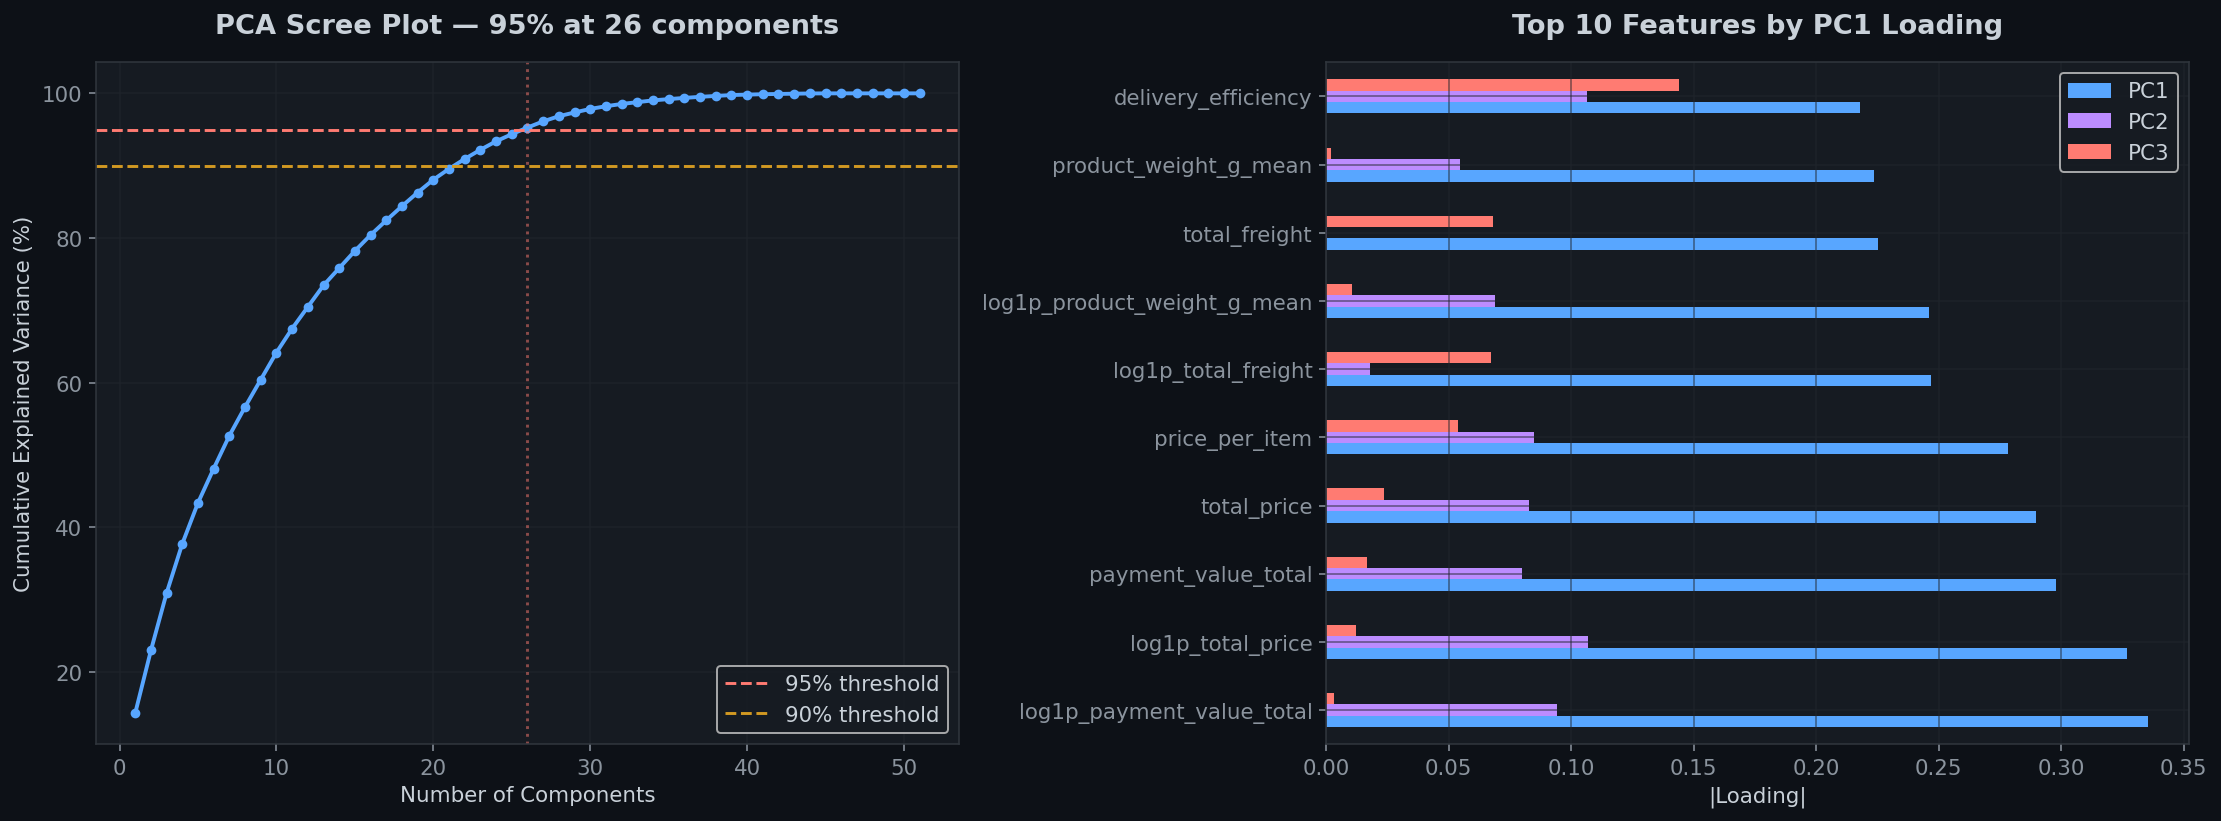

Components for 90% variance: 22
Components for 95% variance: 26


In [7]:
# ── PCA component analysis ────────────────────────────────────────
# Gather strictly numeric attributes for covariance analysis
all_num_eng = [c for c in train_eng.select_dtypes(include=[np.number]).columns if c != 'target_repeat_within_180d']

X_pca_full = train_eng[all_num_eng].fillna(0)
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca_full)

# Fit Unsupervised Principal Components algorithm measuring maximal variance directions
pca_full = PCA(random_state=42)
pca_full.fit(X_pca_scaled)

# Render a 2-Panel figure illustrating PCA diagnostics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Axis: Scree plot tracking how quickly cumulative retained variance climbs
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[0].plot(range(1, len(cumvar)+1), cumvar, '-o', color=PALETTE['primary'], markersize=4, linewidth=2)
axes[0].axhline(y=95, color=PALETTE['accent'], linestyle='--', label='95% threshold')
axes[0].axhline(y=90, color=PALETTE['warning'], linestyle='--', label='90% threshold')
n_95 = np.argmax(cumvar >= 95) + 1
axes[0].axvline(x=n_95, color=PALETTE['accent'], linestyle=':', alpha=0.5)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance (%)')
axes[0].set_title(f'PCA Scree Plot — 95% at {n_95} components', pad=15)
axes[0].legend()

# Right Axis: Observe feature loadings for PC1 to understand what dominant attributes constitute it
loadings = pd.DataFrame(pca_full.components_[:3].T, index=all_num_eng, columns=['PC1', 'PC2', 'PC3'])
top_loadings = loadings.abs().nlargest(10, 'PC1')
top_loadings[['PC1','PC2','PC3']].plot(kind='barh', ax=axes[1], color=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']])
axes[1].set_title('Top 10 Features by PC1 Loading', pad=15)
axes[1].set_xlabel('|Loading|')

plt.tight_layout()
plt.savefig('../final_outputs/pca_scree_loadings.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Components for 90% variance: {np.argmax(cumvar >= 90) + 1}')
print(f'Components for 95% variance: {n_95}')


<details>
<summary><b>Explanation</b></summary>
<br>
Principal Component Analysis measures the inherent "true" dimensional complexity of our dataset. A Scree Plot visualizes how many composite columns we actually need to retain 95% of the information logic from dozens of features. Then, visualizing PC1 'loadings' shows us exactly which original features mathematically drive the most spread in customer behavior.
</details>

### 📊 Interpretation — PCA Analysis
1. **Scree plot**: The cumulative variance curve shows how many components are needed. If 95% variance is reached with significantly fewer components than total features, dimensionality reduction could simplify the model.
2. **PC1 loadings**: The features with highest loadings on PC1 reveal the **primary axis of variation** in the data — typically dominated by monetary features (price, payment, freight) which are highly correlated.
3. **Implication**: While PCA is useful for visualisation and understanding variance structure, we will **not use PCA for feature reduction** in our models because:
   - Tree-based models handle high dimensions well
   - PCA destroys feature interpretability (important for business stakeholders)
   - The domain-engineered features carry business meaning that PCA components do not

---